# Experiment 00: Activation Function Expansion Accuracy

The purpose of this experiment is to assess the accuracy of the expansions developed for the activation functions.  Number of terms and V parameter modifications are explored.


## Setup

In [2]:
%load_ext autoreload
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt

from prism.analysis.expansion_plots import plot_expansion_and_errors

from prism.prism_math.activation_coefs import \
    visual_test_alpha_coefs_tanh, \
    visual_test_alpha_coefs_sech, \
    visual_test_alpha_coefs_sech2, \
    visual_test_alpha_coefs_relu, \
    compute_eta_error_tanh_analytic, compute_eta_error_tanh_approx_large_tau, \
    compute_eta_error_sech_analytic, compute_eta_error_sech_approx_large_sigma, \
    compute_eta_error_sech2_analytic, compute_eta_error_sech2_approx_large_sigma, \
    compute_eta_error_relu_analytic, compute_eta_error_relu_approx_large_sigma

from prism.prism_math.activation_coefs import get_alpha_coefs

from prism.prism_math.polynomials import polyval_cpu

plt.rcParams.update({
    'text.usetex': True,
    'font.family': 'serif',
    'font.serif': ['Palatino'],
    'font.size': 20
})

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Tanh: Number of terms = 8, V = 4

In [3]:
# Expansion parameters
v_max = 4
big_m = 8
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='tanh',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [4]:
dv = 2*1.2*v_max/40
v = np.arange(-1.2*v_max, 1.2*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.tanh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_tanh_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_tanh_approx_large_tau(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [5]:
v_smooth = np.arange(-1.2*v_max, 1.2*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = np.tanh(v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_tanh_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_tanh_approx_large_tau(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

findfont: Font family ['serif'] not found. Falling back to DejaVu Sans.


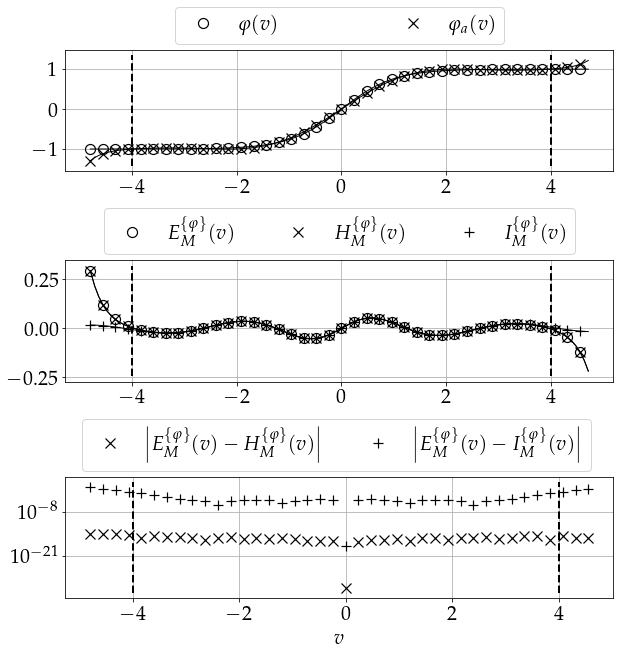

In [6]:
name = './plots/tanh_big_m_8_v_max_4.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## Tanh: Number of terms = 25, V = 20

In [7]:
v_max = 20
big_m = 25
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='tanh',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [8]:
dv = 2*1.2*v_max/60
v = np.arange(-1.05*v_max, 1.05*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = np.tanh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_tanh_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_tanh_approx_large_tau(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [9]:
v_smooth = np.arange(-1.05*v_max, 1.05*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = np.tanh(v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_tanh_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_tanh_approx_large_tau(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

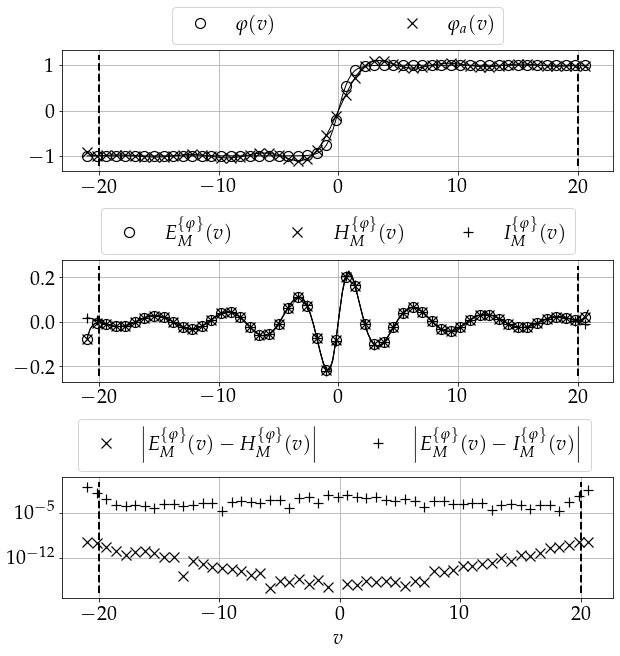

In [10]:
name = './plots/tanh_big_m_25_v_max_20.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## ReLU: Number of terms = 8, V = 4

In [11]:
# Expansion parameters
v_max = 4
big_m = 8
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='relu',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [12]:
dv = 2*1.2*v_max/40
v = np.arange(-1.2*v_max, 1.2*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 0.5*(np.abs(v) + v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_relu_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_relu_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [13]:
v_smooth = np.arange(-1.2*v_max, 1.2*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 0.5*(np.abs(v_smooth) + v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_relu_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_relu_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

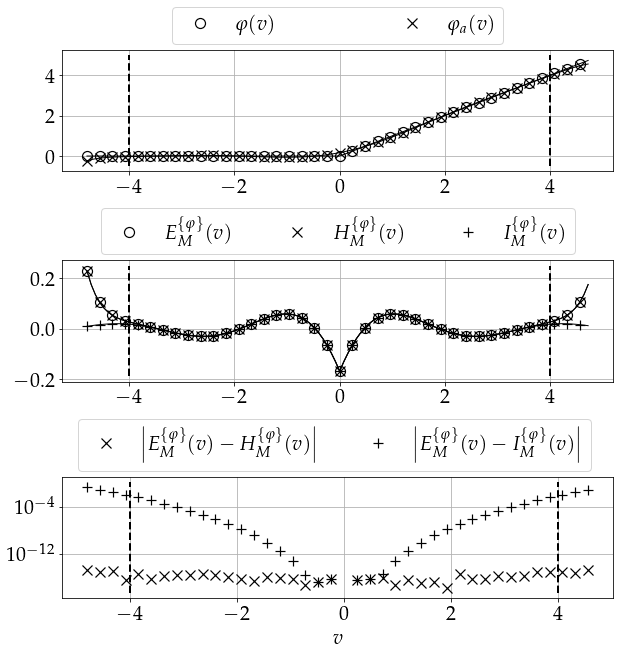

In [14]:
name = './plots/relu_big_m_8_v_max_4.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## ReLU: Number of terms = 25, V = 20

In [15]:
# Expansion parameters
v_max = 20
big_m = 25
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='relu',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [16]:
dv = 2*1.2*v_max/60
v = np.arange(-1.05*v_max, 1.05*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 0.5*(np.abs(v) + v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_relu_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_relu_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [17]:
v_smooth = np.arange(-1.05*v_max, 1.05*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 0.5*(np.abs(v_smooth) + v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_relu_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_relu_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

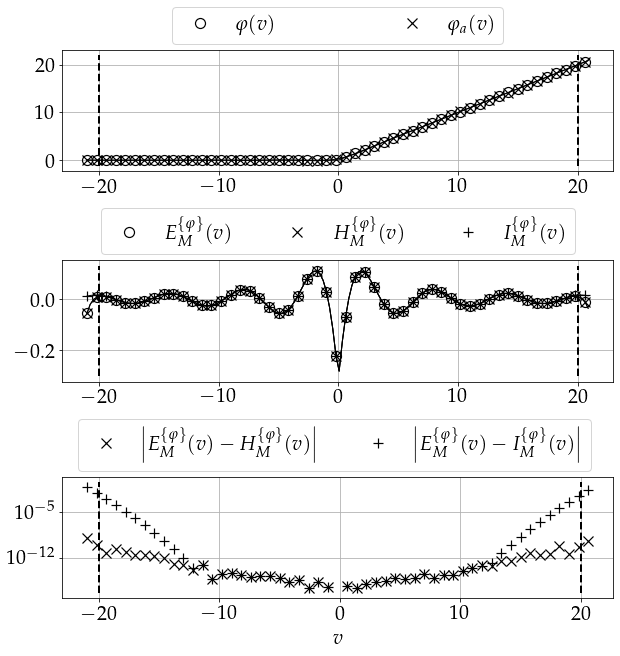

In [18]:
name = './plots/relu_big_m_25_v_max_20.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## Sech: Number of terms = 8, V = 4

In [19]:
# Expansion parameters
v_max = 4
big_m = 8
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='sech',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [20]:
dv = 2*1.2*v_max/40
v = np.arange(-1.2*v_max, 1.2*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 1/np.cosh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_sech_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_sech_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [21]:
v_smooth = np.arange(-1.2*v_max, 1.2*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 1/np.cosh(v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_sech_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_sech_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

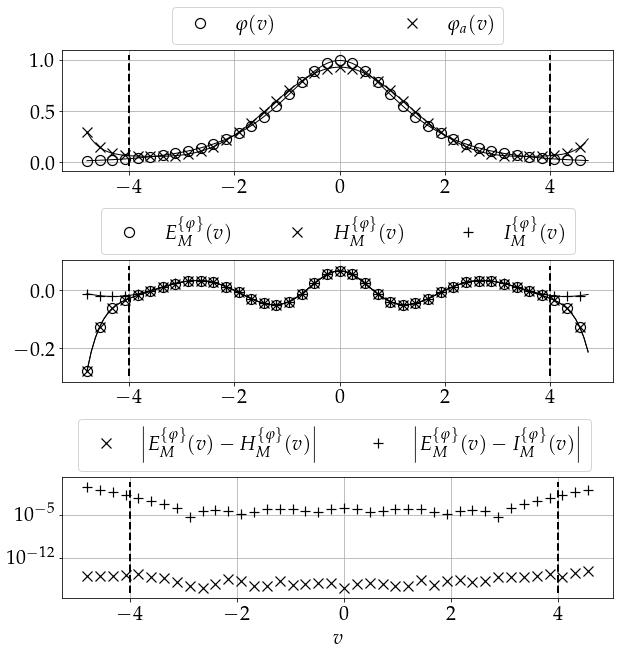

In [22]:
name = './plots/sech_big_m_8_v_max_4.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## Sech: Number of terms = 25, V = 20

In [23]:
# Expansion parameters
v_max = 20
big_m = 25
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='sech',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [24]:
dv = 2*1.2*v_max/40
v = np.arange(-1.05*v_max, 1.05*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 1/np.cosh(v)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_sech_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_sech_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [25]:
v_smooth = np.arange(-1.05*v_max, 1.05*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 1/np.cosh(v_smooth)

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_sech_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_sech_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

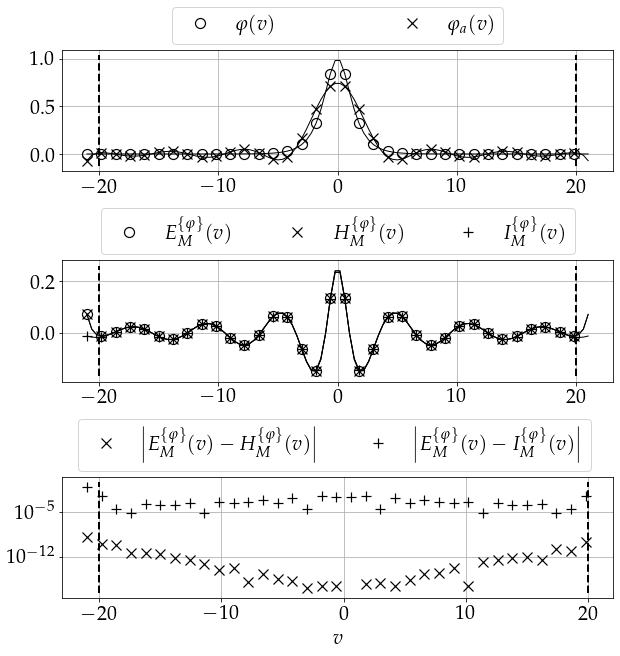

In [26]:
name = './plots/sech_big_m_25_v_max_20.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## Sech^2: Number of terms = 8, V = 4

In [27]:
# Expansion parameters
v_max = 4
big_m = 16
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='sech2',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [28]:
dv = 2*1.2*v_max/40
v = np.arange(-1.2*v_max, 1.2*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 1/(np.cosh(v)**2)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_sech2_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_sech2_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [29]:
v_smooth = np.arange(-1.2*v_max, 1.2*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 1/(np.cosh(v_smooth))**2

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_sech2_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_sech2_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

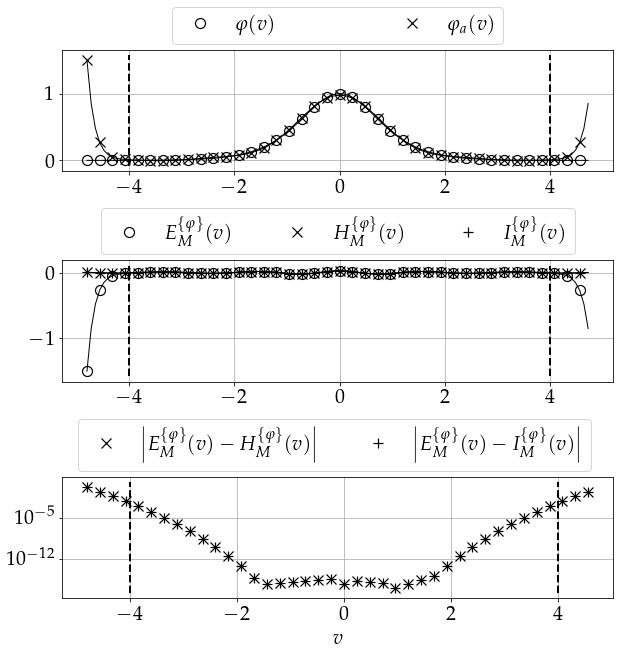

In [30]:
name = './plots/sech2_big_m_16_v_max_4.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)

## Sech^2: Number of terms = 25, V = 20

In [31]:
# Expansion parameters
v_max = 20
big_m = 25
dps = 400

alpha_coefs, exponents, alpha_coefs_float64 = get_alpha_coefs(
        function_type='sech2',
        big_m=big_m, v_max=v_max, dps=dps,
        load_file=None, save=False, silent=True)

In [32]:
dv = 2*1.2*v_max/40
v = np.arange(-1.05*v_max, 1.05*v_max, dv)
y = polyval_cpu(alpha_coefs_float64, exponents, v)
y_true = 1/(np.cosh(v)**2)

error = y_true - y

error_predicted_analytical = \
        compute_eta_error_sech2_analytic(v, big_m, v_max)

error_predicted_approx = \
        compute_eta_error_sech2_approx_large_sigma(v, big_m, v_max)

error_vs_error_predicted_analytical = error - error_predicted_analytical
error_vs_error_predicted_approx = error - error_predicted_approx

In [33]:
v_smooth = np.arange(-1.05*v_max, 1.05*v_max, dv/3)
y_smooth = polyval_cpu(alpha_coefs_float64, exponents, v_smooth)
y_true_smooth = 1/(np.cosh(v_smooth))**2

error_smooth = y_true_smooth - y_smooth

error_predicted_analytical_smooth = \
        compute_eta_error_sech2_analytic(v_smooth, big_m, v_max)

error_predicted_approx_smooth = \
        compute_eta_error_sech2_approx_large_sigma(v_smooth, big_m, v_max)

error_vs_error_predicted_analytical_smooth = error_smooth - error_predicted_analytical_smooth
error_vs_error_predicted_approx_smooth = error_smooth - error_predicted_approx_smooth

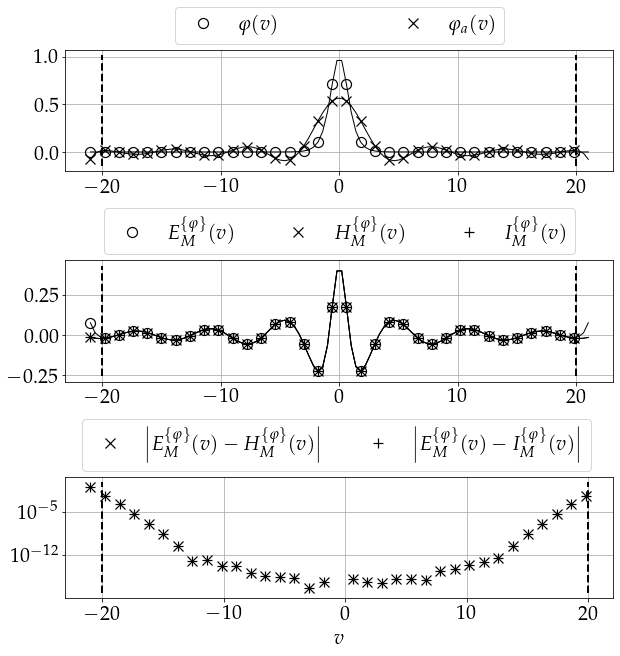

In [34]:
name = './plots/sech2_big_m_25_v_max_20.png'

plot_expansion_and_errors(
    name, v_max,
    v, y, y_true, error,
    error_predicted_analytical,
    error_predicted_approx,
    error_vs_error_predicted_analytical,
    error_vs_error_predicted_approx,
    v_smooth, y_smooth, y_true_smooth, error_smooth,
    error_predicted_analytical_smooth,
    error_predicted_approx_smooth,
    error_vs_error_predicted_analytical_smooth,
    error_vs_error_predicted_approx_smooth
)